# Patient Experience Clustering using Drug Review Data (DrugLib Dataset)

In [5]:
import os
os.chdir("C:/Users/Tarek/OneDrive/Documents/dataCampAssociateAIEngineeDS/unsupervisedLearningPython/data")

## Executive Summary

- The project used NLP techniques, including TF-IDF vectorization and Truncated SVD, to cluster patient drug reviews based on effectiveness and side effects.
- Clustering results (low silhouette, high Davies–Bouldin, no clear elbow) indicate weak separation, suggesting that patient experiences form a continuous spectrum rather than distinct groups.
- A 3-cluster solution was retained for interpretability, identifying typical, moderate, and higher-risk treatment patterns.
- Despite differences in side-effect profiles, patient ratings and sentiment remained consistent, indicating that perceived effectiveness often outweighs adverse effects in overall satisfaction.

## Dataset Source

- Source: [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/461/drug+review+dataset+druglib+com)
- Dataset: Drug Review Dataset (DrugLib.com)
- Files used:
    - drugLibTrain_raw.tsv
    - drugLibTest_raw.tsv

## Problem Statement

Healthcare datasets often contain unstructured patient feedback.

👉 Goal:

- Identify patterns in:
    - Effectiveness
    - Side effects
    - Patient satisfaction
- Support evidence-based health decisions

## Data Understanding

| Column              | Meaning                 | Data Type            |
| ------------------- | ----------------------- |--------------------- |
| id                  | Review ID               | Integer              |
| drug_name           | Medication              | Categorrical         |
| rating              | Patient rating (1–10)   | Integer              |
| effectiveness       | Perceived effectiveness | Categorical          |
| side_effects        | Severity level          | Categorical          |
| condition           | Disease treated         | Categorical          |
| benefits_review     | Positive experience     | Categorical          |
| side_effects_review | Negative experience     | Categorical          |
| dosage_review       | Usage details           | Categorical          |

## 🎯 Project Objective

To analyze patient reviews and:

- Identify patterns in drug effectiveness and side effects
- Cluster patients into experience groups
- Support data-driven healthcare insights

## Import Libraries

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import plotly.express as px
# from sklearn.manifold import TSNE

from sklearn.cluster import KMeans
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import silhouette_score

import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

import warnings
warnings.filterwarnings("ignore")

## Load and Explore the Data

##### 1. Load the Datasets

In [132]:
# Load the TSV file
# sep='\t' tells it to look for tabs
# quoting=0 handles the double quotes around the long text sections
df1 = pd.read_csv('drugLibTrain_raw.tsv', sep='\t')

# Naming the columns based on your data structure
df1.columns = [
    'id', 'drug_name', 'rating', 'effectiveness', 
    'side_effects', 'condition', 'benefits_review', 
    'side_effects_review', 'dosage_review'
]

In [133]:
df2 = pd.read_csv('drugLibTest_raw.tsv', sep='\t')

# Naming the columns based on your data structure
df2.columns = [
    'id', 'drug_name', 'rating', 'effectiveness', 
    'side_effects', 'condition', 'benefits_review', 
    'side_effects_review', 'dosage_review'
]

##### 2. Merge the Dataframes, Vertically

In [134]:
drug_reviews_df = pd.concat([df1, df2])
drug_reviews_df.head()

,id,drug_name,rating,effectiveness,side_effects,condition,benefits_review,side_effects_review,dosage_review
0,2202,enalapril,4,Highly Effective,Mild Side Effects,management of congestive heart failure,slowed the progression of left ventricular dys...,"cough, hypotension , proteinuria, impotence , ...","monitor blood pressure , weight and asses for ..."
1,3117,ortho-tri-cyclen,1,Highly Effective,Severe Side Effects,birth prevention,Although this type of birth control has more c...,"Heavy Cycle, Cramps, Hot Flashes, Fatigue, Lon...","I Hate This Birth Control, I Would Not Suggest..."
2,1146,ponstel,10,Highly Effective,No Side Effects,menstrual cramps,I was used to having cramps so badly that they...,Heavier bleeding and clotting than normal.,I took 2 pills at the onset of my menstrual cr...
3,3947,prilosec,3,Marginally Effective,Mild Side Effects,acid reflux,The acid reflux went away for a few months aft...,"Constipation, dry mouth and some mild dizzines...",I was given Prilosec prescription at a dose of...
4,1951,lyrica,2,Marginally Effective,Severe Side Effects,fibromyalgia,I think that the Lyrica was starting to help w...,I felt extremely drugged and dopey. Could not...,See above


##### 3. Explore the Data

In [135]:
# Extract the info of the features' dataframe
drug_reviews_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4143 entries, 0 to 1035
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   id                   4143 non-null   int64 
 1   drug_name            4143 non-null   object
 2   rating               4143 non-null   int64 
 3   effectiveness        4143 non-null   object
 4   side_effects         4143 non-null   object
 5   condition            4142 non-null   object
 6   benefits_review      4120 non-null   object
 7   side_effects_review  4045 non-null   object
 8   dosage_review        4130 non-null   object
dtypes: int64(2), object(7)
memory usage: 323.7+ KB


In [136]:
# The average rating
print(drug_reviews_df['rating'].mean().round())

7.0


## TF-IDF Vectorization and NLP

- Natural Language Processing (NLP) techniques were applied to transform unstructured patient reviews into structured numerical data. Text preprocessing included normalization (lowercasing, noise removal), stopword filtering, and domain-specific adjustments to preserve meaningful medical phrases (e.g., “side_effects”).

- The cleaned text was then vectorized using TF-IDF (Term Frequency–Inverse Document Frequency) via scikit-learn. This approach assigns higher weights to terms that are frequent within a document but less common across the dataset, enabling the model to capture informative and distinguishing features.

- To enhance semantic representation, n-grams (unigrams and bigrams) were used, allowing the model to capture clinically relevant phrases such as “abdominal pain” and “no_side_effects.” This significantly improved feature quality and interpretability.

- Given the high dimensionality of TF-IDF features, Truncated SVD was applied to reduce dimensionality while preserving the most important variance in the data. The resulting feature space was then used for clustering analysis.

**1. Text Data Processing**

In [150]:
# Handle missing values
drug_reviews_df['side_effects_review'] = drug_reviews_df['side_effects_review'].fillna('')

lemmatizer = WordNetLemmatizer()

# Cleans raw text by lowercasing, removing noise, and filtering stopwords for NLP processing
def clean_text(text): 
    text = text.lower()
    
    # Preserve important phrases
    text = text.replace("side effects", "side_effects")
    text = text.replace("adverse side effects", "adverse_side_effects")
    
    # Handle negations
    text = re.sub(r'\bno\b', 'no_', text)
    text = re.sub(r'\bnot\b', 'not_', text)

    # Improve negation
    text = re.sub(r'no side effects', 'no_side_effects', text)
    text = re.sub(r'no pain', 'no_pain', text)
    
    # Remove noise
    text = re.sub(r'[^a-zA-Z0-9_]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    
    # Tokenize + remove stopwords
    tokens = text.split()
    tokens = [w for w in tokens if w not in ENGLISH_STOP_WORDS]

    # Remove meaningless standalone numbers
    tokens = [w for w in tokens if not w.isdigit()]

    # Normalize dosage expressions
    text = re.sub(r'(\d+)\s*mg', r'\1mg', text)
    
    # Lemmatize
    tokens = [lemmatizer.lemmatize(w) for w in tokens]
    
    return " ".join(tokens)

# Apply cleaning
drug_reviews_df['clean_text'] = drug_reviews_df['side_effects_review'].apply(clean_text)

**2. TF-IDF**

- Vectorize the text using TF-IDF
- Remove 'english' stop words (like 'the', 'is') and domain stopwords to focus on medical terms

In [157]:
domain_stopwords = [
    "actually", "basically", "apparently", "ability",
    "anymore", "away", "bit", "big", "best", "better"
]

custom_stopwords = list(ENGLISH_STOP_WORDS.union(domain_stopwords))

vectorizer = TfidfVectorizer(
    max_features=3000,
    ngram_range=(1, 2),     # captures phrases like "side_effects"
    min_df=10,              # ignore rare words
    max_df=0.7,             # ignore overly common words
    stop_words=custom_stopwords
)

X = vectorizer.fit_transform(drug_reviews_df['clean_text'])

In [176]:
# Get feature names
feature_names = vectorizer.get_feature_names_out()

**3. SVD (Dimensionality Reduction)**

In [177]:
# Apply TruncatedSVD to reduce dimensionality
svd = TruncatedSVD(n_components=100, random_state=42)
X_reduced = svd.fit_transform(X)

## K-Means Clustering

##### 1. Determine the Number of Clusters using Elbow Method

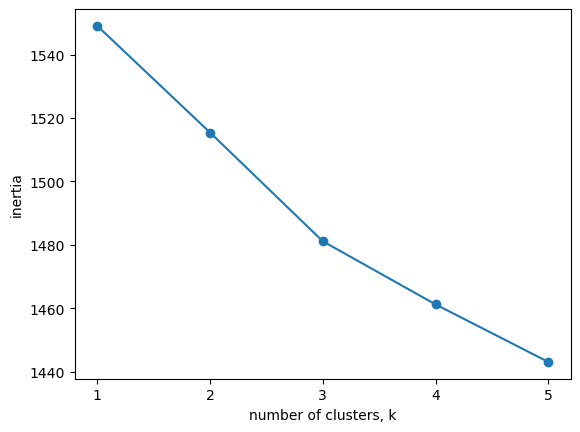

In [175]:
ks = range(1, 6)
inertias = []

for k in ks:
    # Create a KMeans instance with k clusters: model
    model = KMeans(n_clusters = k, random_state = 42)
    
    # Fit model to samples
    model.fit(X_reduced)
    
    # Append the inertia to the list of inertias
    inertias.append(model.inertia_)
    
# Plot ks vs inertias
plt.plot(ks, inertias, '-o')
plt.xlabel('number of clusters, k')
plt.ylabel('inertia')
plt.xticks(ks)
plt.show()

Based on the elbow method, k=3 was selected as it represents the point where inertia reduction starts to slow down significantly, indicating an optimal balance between model complexity and explained variance.

##### 2. Fit a K-Merans Model

In [161]:
kmeans = KMeans(n_clusters=3, random_state=42)
drug_reviews_df['cluster'] = kmeans.fit_predict(X_reduced)
drug_reviews_df['cluster'] = kmeans.labels_ + 1

## Sentiment Analysis

In [162]:
from textblob import TextBlob

drug_reviews_df['sentiment'] = drug_reviews_df['clean_text'].apply(
    lambda x: TextBlob(x).sentiment.polarity
)

In [163]:
drug_reviews_df.groupby('cluster')[['rating', 'sentiment']].mean().round(2)

,rating,sentiment
cluster,,
1,7.18,-0.02
2,6.93,-0.01
3,6.99,-0.00


In [164]:
def sentiment_label(score):
    if score > 0.1:
        return "Positive"
    elif score < -0.1:
        return "Negative"
    else:
        return "Neutral"

drug_reviews_df['sentiment_label'] = drug_reviews_df['sentiment'].apply(sentiment_label)

### Visualizing Patients Reviews and Side Effects

**1. Count Patients per Group**

In [183]:
combined_table = (
    drug_reviews_df
    .groupby(["cluster", "effectiveness", "side_effects"])
    .size()
    .reset_index(name="count")
)

**2. Convert to percentages (within each cluster)**

In [184]:
# Calculate percentage relative to each cluster
combined_table['percentage'] = round((
    combined_table['count'] / 
    combined_table.groupby('cluster')['count'].transform('sum')
) * 100, 2)

# Optional: Drop the 'count' column if you only want to see the percentage
percentage_table = combined_table.drop(columns=['count'])

**3. Average Rating per Cluster**

In [185]:
avg_ratings = drug_reviews_df.groupby('cluster')['rating'].mean().round(2).to_dict()

**4. Relabel Effectiveness groups** 

In [186]:
label_map = {
    "Highly Effective": "High",
    "Considerably Effective": "Considerable",
    "Moderately Effective": "Moderate",
    "Marginally Effective": "Marginal",
    "Ineffective": "Ineffective"
}

percentage_table['effectiveness_short'] = percentage_table['effectiveness'].map(label_map)

In [187]:
percentage_table.head()

,cluster,effectiveness,side_effects,percentage,effectiveness_short
0,1,Considerably Effective,Extremely Severe Side Effects,0.57,Considerable
1,1,Considerably Effective,Mild Side Effects,19.89,Considerable
2,1,Considerably Effective,Moderate Side Effects,9.09,Considerable
3,1,Considerably Effective,No Side Effects,2.27,Considerable
4,1,Considerably Effective,Severe Side Effects,1.70,Considerable


**5. Indexed Columns**

In [190]:
clusters = percentage_table['cluster'].unique()
effectiveness = percentage_table['effectiveness_short'].unique()
side_effects = percentage_table['side_effects'].unique()

full_index = pd.MultiIndex.from_product(
    [clusters, effectiveness, side_effects],
    names=['cluster', 'effectiveness_short', 'side_effects']
)

percentage_table = percentage_table.set_index(['cluster', 'effectiveness_short', 'side_effects']) \
       .reindex(full_index, fill_value=0) \
       .reset_index() \
       .drop("effectiveness", axis=1)

In [191]:
percentage_table

,cluster,effectiveness_short,side_effects,percentage
0,1,Considerable,Extremely Severe Side Effects,0.57
1,1,Considerable,Mild Side Effects,19.89
2,1,Considerable,Moderate Side Effects,9.09
3,1,Considerable,No Side Effects,2.27
4,1,Considerable,Severe Side Effects,1.70
...,...,...,...,...
70,3,Moderate,Extremely Severe Side Effects,0.32
71,3,Moderate,Mild Side Effects,6.47
72,3,Moderate,Moderate Side Effects,9.06
73,3,Moderate,No Side Effects,1.94


**6. Visualize Patients Experience**

In [249]:
# Define the descriptive labels
cluster_labels = {
    1: "High-Efficacy / Moderate-Burden Treatments",
    2: "High-Tolerability Treatments",
    3: "High-Adverse-Risk Treatments"
}

# Show only labels that are meaningful (more than 5%)
percentage_table['label'] = percentage_table['percentage'].apply(lambda x: f"{x:.0f}%" if x > 5 else "")

fig = px.bar(
    percentage_table, 
    x='effectiveness_short', 
    y='percentage', 
    color='side_effects', 
    facet_col='cluster',
    facet_col_spacing=0.06,  
    text="label",
    category_orders={
        "effectiveness_short": ["High", "Considerable", "Moderate", "Marginal", "Ineffective"],
        "cluster": [2, 1, 3]
    },
    title="Drug Effectiveness and Side Effects<br>by Cluster",
    width=1000,              
    height=500
)

fig.update_traces(textposition='inside')

# Highlight best cluster
fig.add_annotation(
    text="⭐ Best Cluster",
    xref="x domain",
    yref="y domain",
    x=0.5,
    y=1,
    showarrow=False,
    font=dict(size=12),
    bgcolor="lightgreen",
    bordercolor="green",
    borderwidth=1
)

# Improve subplot titles
for annotation in fig.layout.annotations:
    if 'cluster=' in annotation.text:
        cluster_id = int(annotation.text.split('=')[-1])
        label = cluster_labels.get(cluster_id, "Unknown")
        rating = avg_ratings.get(cluster_id, None)
        
        rating_text = f"{rating:.1f}" if isinstance(rating, (int, float)) else "N/A"

        annotation.text = (
            f"<b>Cluster {cluster_id}</b><br>"
            f"{label}<br>"
            f"<span style='font-size:11px'>Avg Rating: {rating_text}</span>"
        )

# Axis cleanup
fig.update_xaxes(title_text='')
fig.update_yaxes(title_text='')
fig.update_layout(
    yaxis_title_text='Patient Percentage (%)',
    margin=dict(t=110, b=80),
    legend_title_text="Side Effects Severity"
)

# Update title 
fig.update_layout(
    title=dict(
        text="<b>Drug Effectiveness and Side Effects<br>by Cluster</b>",
        x=0.4,          # center horizontally
        xanchor='center',
        y=0.9,         # move title higher
        yanchor='top',
        font=dict(size=16)
    ),
    margin=dict(t=140, b=80),  # increase top margin to create space
)

# Add data source
fig.add_annotation(
    text="Source: UCI Machine Learning Repository – Drug Reviews (Druglib.com) <br> Processed by Tarek Dib",
    x=0.5,
    xanchor="center",
    y=-0.3,
    xref="paper",
    yref="paper",
    showarrow=False,
    font=dict(size=11, color="gray")
)

fig.show()

In [196]:
drug_reviews_df['cluster'].value_counts()

cluster
2    3658
3     309
1     176
Name: count, dtype: int64

In [202]:
round(drug_reviews_df['cluster'].value_counts(normalize=True)*100, 1)

cluster
2    88.3
3     7.5
1     4.2
Name: proportion, dtype: float64

- The clustering results show a dominant patient group (88.3%) alongside smaller but distinct subgroups, indicating that most patients share similar treatment experiences, with a minority exhibiting different response patterns.

- The imbalance suggests that clustering is capturing deviations from a dominant baseline rather than evenly distributed segments, which is typical in real-world patient data.

**7. Evaluation**

In [194]:
scores = {}

for k in range(2, 6):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_reduced)
    score = silhouette_score(X_reduced, labels)
    scores[k] = score
    print(f"k={k}, silhouette score={score:.4f}")

k=2, silhouette score=0.0649
k=3, silhouette score=0.0697
k=4, silhouette score=0.0731
k=5, silhouette score=0.0721


- Although k=4 produced the highest silhouette score, the improvement over k=3 was marginal. Therefore, k=3 was retained to preserve interpretability and avoid over-segmentation. 
- The data have weak cluster separation, and increasing k only gives marginal gains.

- The data are:
    - ✔ High-dimensional (TF-IDF)
    - ✔ Noisy (text data)
    - ✔ Continuous (patient experiences)

👉 So:

- Low silhouette scores are expected
- The goal is interpretability, not perfect separation

In [195]:
from sklearn.metrics import davies_bouldin_score

db_score = davies_bouldin_score(X_reduced, labels)
print("Davies-Bouldin Score:", db_score)

Davies-Bouldin Score: 3.11556922111451


Clustering evaluation metrics (Silhouette ≈ 0.07 and Davies–Bouldin ≈ 3.1) indicate weak separation between clusters. This suggests that patient experiences form a continuous spectrum rather than distinct groups. Therefore, clustering results are interpreted as relative patterns rather than strict segments.

## Conclusions

This project applied NLP-driven clustering to patient drug reviews to explore patterns in treatment effectiveness and side-effect burden. Text data were preprocessed using domain-aware cleaning techniques and transformed into numerical features using TF-IDF. To address high dimensionality and sparsity, Truncated SVD was applied prior to clustering.

Despite dimensionality reduction, clustering evaluation metrics consistently indicated weak separation between clusters. Silhouette scores remained low (~0.07 across k values), and the Davies–Bouldin Index was relatively high (~3.12), while the elbow method showed no clear inflection point. These results suggest that the dataset does not contain strongly separable groups, but rather represents a continuous spectrum of patient experiences.

A k = 3 solution was retained based on interpretability and analytical usefulness. The resulting clusters reflect relative patterns rather than strictly defined segments:

- A high-tolerability cluster characterized by strong effectiveness and minimal side effects (dominant group),
- A moderate-burden cluster with balanced outcomes,
- A higher-risk cluster associated with more severe side effects and lower effectiveness.

Importantly, cluster-level ratings and sentiment scores showed minimal variation across groups, with average ratings remaining close (~6.9–7.2) and sentiment near neutral. This indicates that differences in side-effect severity do not strongly translate into differences in overall patient satisfaction. In practice, this suggests that perceived treatment effectiveness may outweigh adverse effects, with patients willing to tolerate side effects if therapeutic benefits are achieved.

The presence of a dominant cluster alongside smaller subgroups further indicates that clustering captures deviations from a common baseline experience, rather than clearly separated populations. Additionally, the application of Truncated SVD did not significantly improve cluster separability, reinforcing that the limitation lies in the intrinsic structure of the data, not the modeling approach.

**Key Takeaway**

Patient-reported treatment experiences are best understood as a continuum, where clustering reveals meaningful patterns of variation, and overall satisfaction remains relatively stable despite differences in side-effect burden.

**Limitations**
- Weak cluster separation limits predictive or prescriptive use
- High overlap in vocabulary across patient experiences reduces separability
- K-Means may not fully capture complex structures in text data